MOVIE RATING PREDICTION WITH PYTHON

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

Load Dataset

In [2]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


Basic Information

In [3]:
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape : (15509, 10)

Columns:
Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor

Data Cleaning

Remove unnecessary spaces from column names

In [4]:
df.columns = df.columns.str.strip()

Drop rows where Rating is missing

In [5]:
df = df.dropna(subset=['Rating'])

Fill missing values

In [6]:
df['Genre'] = df['Genre'].fillna('Unknown')
df['Director'] = df['Director'].fillna('Unknown')
df['Actor 1'] = df['Actor 1'].fillna('Unknown')

Convert Rating to numeric

In [7]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

Remove rows with invalid ratings

In [8]:
df = df.dropna(subset=['Rating'])

print("\nAfter Cleaning Shape :", df.shape)


After Cleaning Shape : (7919, 10)


Data Visualization

Rating Distribution

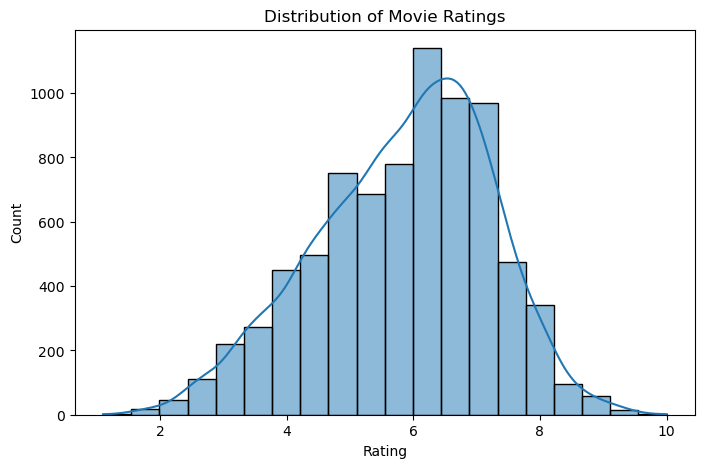

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Top 10 Genres

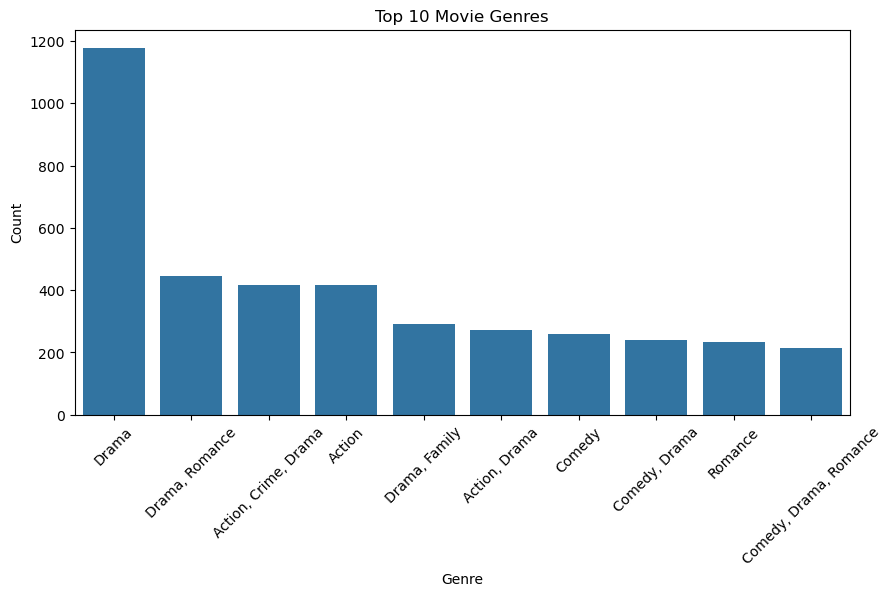

In [10]:
top_genres = df['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Top Directors

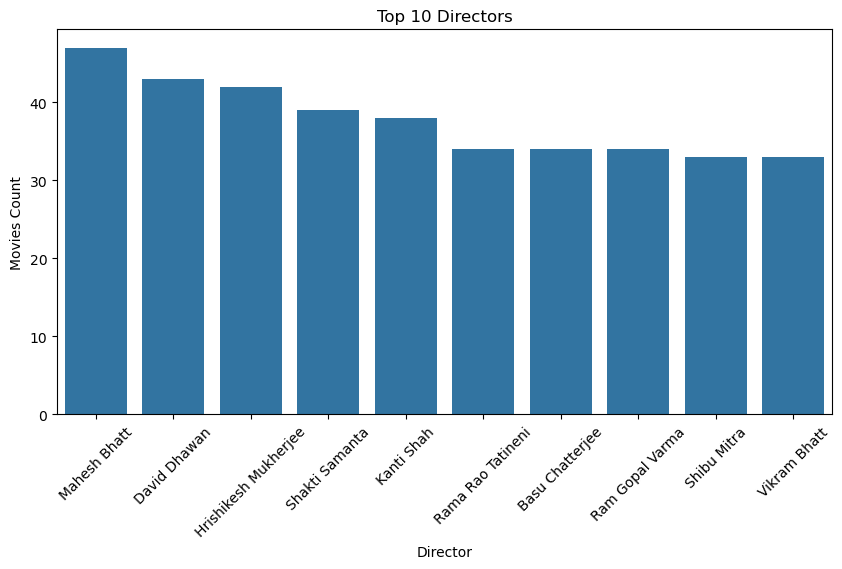

In [11]:
top_directors = df['Director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.index, y=top_directors.values)
plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Movies Count")
plt.xticks(rotation=45)
plt.show()

Feature Engineering

Select useful columns

In [12]:
data = df[['Genre', 'Director', 'Actor 1', 'Rating']].copy()

le_genre = LabelEncoder()
le_director = LabelEncoder()
le_actor = LabelEncoder()

data['Genre'] = le_genre.fit_transform(data['Genre'])
data['Director'] = le_director.fit_transform(data['Director'])
data['Actor 1'] = le_actor.fit_transform(data['Actor 1'])

print(data.head())

   Genre  Director  Actor 1  Rating
1    268       811     1782     7.0
3    207      1749     1589     4.4
5    177      2005      508     4.7
6    331      2643      931     7.4
8    367       174     2521     5.6


Define Features and Target

In [13]:
X = data[['Genre', 'Director', 'Actor 1']]
y = data['Rating']

Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (6335, 3)
Testing Data Shape : (1584, 3)


Model Training

In [15]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


Prediction

In [16]:
y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred[:10])


Predictions:
[4.614      6.134      5.717      6.708      4.68072208 6.355
 5.88       6.059      6.10633333 5.645     ]


Model Evaluation

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)


Model Evaluation
Mean Absolute Error : 1.0215131429054252
Mean Squared Error : 1.6815457196220445
Root Mean Squared Error : 1.2967442768803896
R2 Score : 0.09552746428345671


Actual vs Predicted Visualization

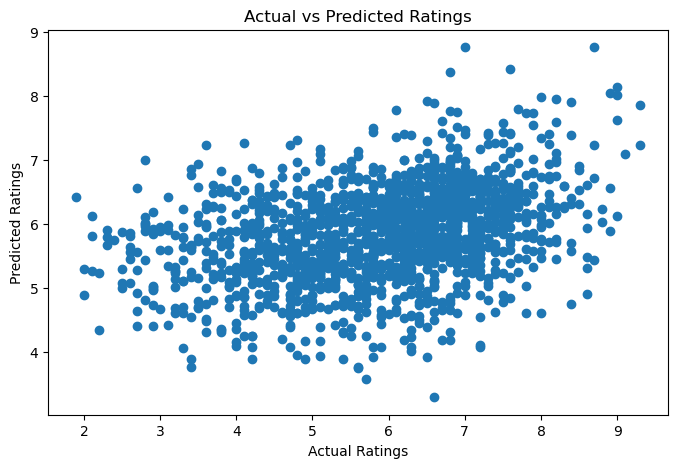

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

 Sample Prediction

In [19]:
sample_input = pd.DataFrame({
    'Genre': [le_genre.transform(['Drama'])[0]],
    'Director': [le_director.transform(['Unknown'])[0]],
    'Actor 1': [le_actor.transform(['Unknown'])[0]]
})

sample_prediction = model.predict(sample_input)

print("\nPredicted Rating :", sample_prediction[0])


Predicted Rating : 6.631999999999993
